In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

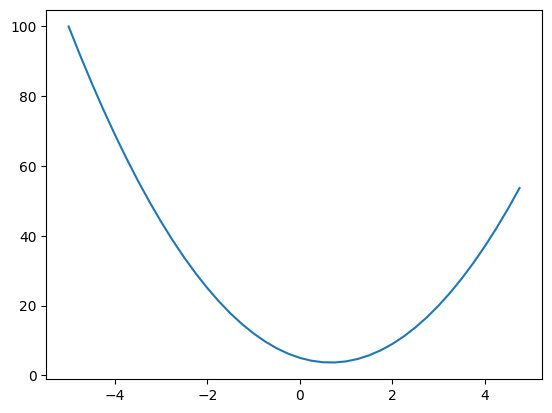

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.001
x = -3.0
(f(x + h) - f(x))/h

-21.996999999998934

In [6]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a +=h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [7]:
class Value:

    def __init__(self, _data, _children=(), _op='', _label='', _grad=0.0):
        self._data = _data
        self._grad = _grad
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self._label = _label

    def __repr__(self):
        return f"Value(_data={self._data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self._data) + (other._data), (self, other), '+')

        # requires += for accumulation to handle redundant inputs
        def _backward():
            self._grad += out._grad
            other._grad += out._grad
            
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self._data) * (other._data), (self, other), '*')
        
        def _backward():
            self._grad += other._data*out._grad
            other._grad += self._data*out._grad
            
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self*other

    def __truediv__(self, other):
        return self * other**-1

    def tanh(self):
        x = self._data
        t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self._grad += (1 - t**2) * out._grad
            
        out._backward = _backward
        return out

    def exp(self):
        x = self._data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self._grad += out._data * out._grad
            
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "exponent must be integer or float."
        out = Value(self._data**other, (self, ), f'**{other}')

        def _backward():
            self._grad += other * self._data**(other-1) * out._grad

        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self._grad = 1.0
        
        for node in reversed(topo):
            node._backward()


In [8]:
a = Value(3.0)
b = Value(-6.0)
4+a

Value(_data=7.0)

In [9]:
# define simple expression

a = Value(2.0, _label='a')
b = Value(-3.0, _label='b')
d = Value(10.0, _label='d')
c = a*b; c._label = 'c'
e = c+d; e._label = 'e'
f = Value(-2.0, _label='f')
L = e*f; L._label='L'

In [10]:
from graphviz import Digraph
# visualize network with graphviz

def trace(root):
    # builds graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # create a rectangular "record" node for all Values in the graph
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n._label, n._data, n._grad), shape='record')
        
        if n._op:
            # if current Value is a result of an operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            # connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)

    return dot

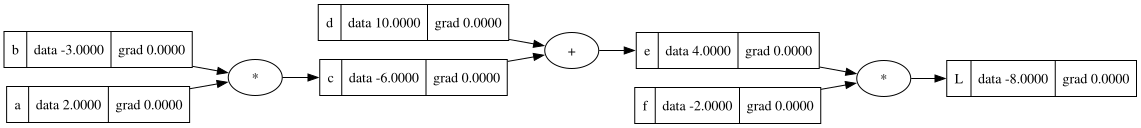

In [11]:
# visualize the graph
draw_dot(L)

gradient of added nodes:

df/dx = f(x+h) - f(x) / h

e = d+f
de/dd = (d+f+h) - d+f / h
h / h
1

gradient of multiplied nodes:

df(x)/dx = f(x+h) - f(x) / h

L = d*f
dL/dd = (d+h)*f - d*f / h
df + hf - df /h
hf/h
h

In [12]:
# manual backpropagation
L._grad = 1.0
f._grad = 4.0
e._grad = -2.0
d._grad = -2.0
c._grad = -2.0
b._grad = -4.0
a._grad = 6.0

In [13]:
# checking gradients numericaly 

def foo():
    h = 0.0001
    
    a = Value(2.0, _label='a')
    b = Value(-3.0, _label='b')
    d = Value(10.0, _label='d')
    c = a*b; c._label = 'c'
    e = c+d; e._label = 'e'
    f = Value(-2.0, _label='f')
    L = e*f; L._label='L'
    L1 = L

    a = Value(2.0, _label='a')
    b = Value(-3.0 + h, _label='b')
    d = Value(10.0, _label='d')
    c = a*b; c._label = 'c'
    e = c+d; e._label = 'e'
    e._data = e._data
    f = Value(-2.0, _label='f')
    L = e*f; L._label='L'
    L2 = L

    print((L2._data-L1._data)/h)

foo()

-4.000000000008441


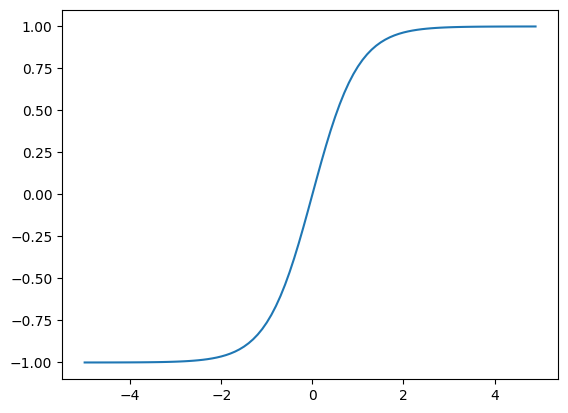

In [14]:
# activation function: tanh
plt.plot(np.arange(-5,5,0.1), np.tanh(np.arange(-5,5,0.1)))

In [15]:
# define node graph

x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
b = Value(6.8813735870165432, _label='b')
x1w1 = x1*w1; x1w1._label='x1w1'
x2w2 = x2*w2; x2w2._label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label='x1w1 + x2w2'
n = x1w1x2w2 + b; n._label = 'n'
o = n.tanh(); o._label='o'

In [16]:
# manual backpropagation

o._grad = 1.0
# do/dn = 1 - o^2
n._grad = o._data**2
b._grad = 0.5
x1w1x2w2._grad = 0.5
x1w1._grad = 0.5
x2w2._grad = 0.5
x1._grad = w1._data*x1w1._grad
w1._grad = x1._data*x1w1._grad
x2._grad = w2._data*x2w2._grad
w2._grad = x2._data*x2w2._grad

In [17]:
# backpropagation through the _backward method, manually executed

o._grad = 1.0
o._backward()
n._backward()
b._backward() # no effect
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [18]:
# backpropagate using Class method

o.backward()

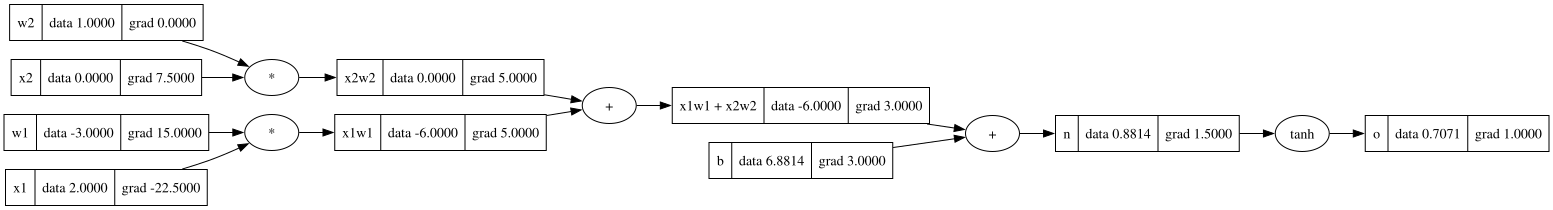

In [19]:
# print graph
draw_dot(o)

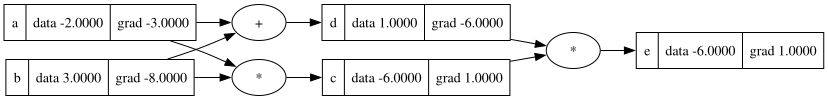

In [20]:
# network which requires accumulation

a = Value(-2.0, _label='a')
b = Value(3.0, _label='b')
c = a*b; c._label='c'
d = a+b; d._label='d'
e = c*d; e._label='e'

e.backward()

draw_dot(e)

In [21]:
# define node graph with atomic tanh

x1 = Value(2.0, _label='x1')
x2 = Value(0.0, _label='x2')
w1 = Value(-3.0, _label='w1')
w2 = Value(1.0, _label='w2')
b = Value(6.8813735870165432, _label='b')
x1w1 = x1*w1; x1w1._label='x1w1'
x2w2 = x2*w2; x2w2._label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label='x1w1 + x2w2'
n = x1w1x2w2 + b; n._label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1)
o._label='o'
o.backward()

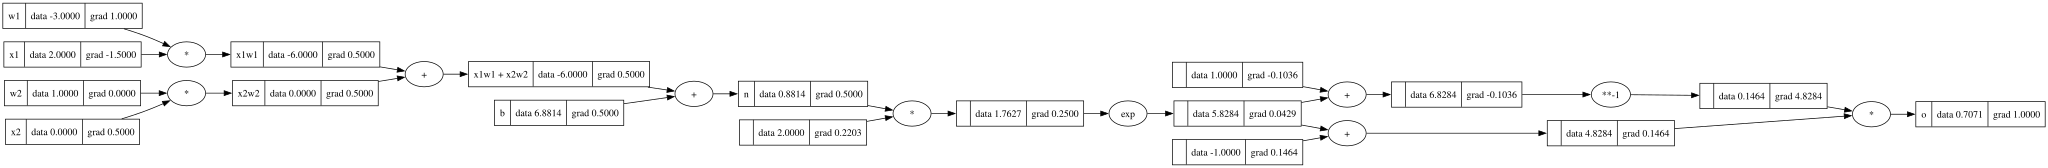

In [22]:
draw_dot(o)

In [23]:
import torch

In [24]:
# define node graph with pytorch

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870165432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0


In [126]:
# building classes to handle MLP

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w*x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):        
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):      
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [172]:
x = [2.0, 3.0, -1.0] # example input vector

n = MLP(3, [4,4,1]) # define MLP: 3-4-4-1

n(x) # output of the MLP

Value(_data=0.496649730585684)

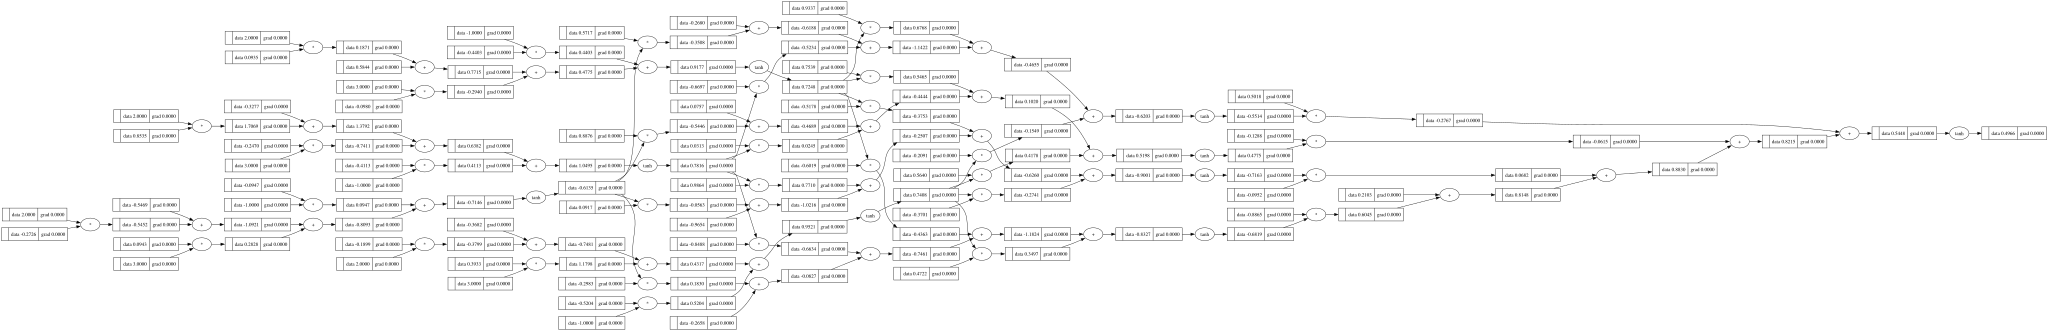

In [173]:
draw_dot(n(x)) # prints the entire 3,4,4,1 MLP

In [246]:
# training example

n = MLP(3, [4,4,1]) # define MLP: 3-4-4-1

training_inputs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]]

training_outputs = [1.0, -1.0, -1.0, 1.0]

In [235]:
# calculate gradients wrt loss
loss.backward()

In [174]:
# calculating loss of neural network
predictions = [n(x) for x in training_inputs]
loss = 0

print("loss = sum of (predicted-actual)^2 over all training examples")
print("n = MLP(3, [4,4,1])\n")
for i in range(1,len(training_inputs)):
    MSE = (predictions[i] - training_outputs[i])**2
    print(f"n({training_inputs[i]}) = {round(predictions[i]._data, 4)} | actual value = {training_outputs[i]} | MSE = {round(MSE._data, 4)}")
    loss += MSE
print(f"\nloss = {round(loss._data, 4)}")


loss = sum of (predicted-actual)^2 over all training examples
n = MLP(3, [4,4,1])

n([3.0, -1.0, 0.5]) = 0.6805 | actual value = -1.0 | MSE = 2.824
n([0.5, 1.0, 1.0]) = 0.2953 | actual value = -1.0 | MSE = 1.6778
n([1.0, 1.0, -1.0]) = 0.6104 | actual value = 1.0 | MSE = 0.1518

loss = 4.6536


In [180]:
# parameters of a single neuron in the network
print(n.layers[0].neurons[0].w[0]._data)
print(n.layers[0].neurons[0].w[0]._grad)

-0.28086935019720405
0.41457482376096766


In [180]:
# the neuron value has changed according to gradient to minimize loss
print(n.layers[0].neurons[0].w[0]._data)

-0.28086935019720405
0.41457482376096766


In [236]:
# nudge values by gradient
for p in n.parameters():
    p._data += -0.01*p._grad

In [247]:
# gradient descent

learning_rate = 0.05

for k in range(20):    
    # forward pass - calculate loss
    predictions = [n(x) for x in training_inputs]
    loss = sum((pred - true)**2 for pred, true in zip(predictions, training_outputs))

    # reverse pass - calculate gradient wrt loss
    for p in n.parameters():
        p._grad = 0.0
    loss.backward()

    # update parameters by gradient
    for p in n.parameters():
        p._data += -learning_rate * p._grad

    print(f"step {k}: loss = {loss._data}")

step 0: loss = 6.575934686691731
step 1: loss = 2.690942947464017
step 2: loss = 1.5392945633303028
step 3: loss = 0.9396644411744652
step 4: loss = 0.5979544933426771
step 5: loss = 0.4077487926286416
step 6: loss = 0.3044003650067507
step 7: loss = 0.23931518966102877
step 8: loss = 0.1951015524448748
step 9: loss = 0.16353906570102963
step 10: loss = 0.14008519888824222
step 11: loss = 0.12208036566191209
step 12: loss = 0.107885398451673
step 13: loss = 0.0964442587245582
step 14: loss = 0.08705026390473992
step 15: loss = 0.07921486123115007
step 16: loss = 0.07259068234846412
step 17: loss = 0.06692465327603304
step 18: loss = 0.06202843214371318
step 19: loss = 0.05775920327179723
